# 0. Import Modules

In [1]:
import torch
torch.__version__

'2.7.1+cu128'

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Aug_20_13:58:20_Pacific_Daylight_Time_2025
Cuda compilation tools, release 13.0, V13.0.88
Build cuda_13.0.r13.0/compiler.36424714_0


In [3]:
!nvidia-smi

Mon Dec  1 17:45:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 34%   36C    P8             11W /  285W |    1311MiB /  12282MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 2 Set parameters and Train Model

## Usage Examples

### Combined BCE + Dice Loss (RECOMMENDED for imbalanced segmentation):
```python
train_unet_pipeline(
    reserves=['ESK'],
    maire_weight=10,
    lr=0.02,
    loss_type='bce_dice',  # Combines pixel-wise + region overlap
    scheduler_metric='iou'  # Use IoU for LR scheduling
)
```

### Weighted Dice Loss (IoU-based with class importance):
```python
train_unet_pipeline(
    reserves=['ESK'],
    maire_weight=10,  # Weight applied to maire class in Dice calculation
    lr=0.02,
    loss_type='dice',  # Weighted Dice: more penalty when maire dice is low
    scheduler_metric='iou'
)
```

### Unweighted Dice Loss (pure IoU optimization):
```python
train_unet_pipeline(
    reserves=['ESK'],
    maire_weight=10,  # Not used for unweighted dice
    lr=0.02,
    loss_type='dice_unweighted',  # All classes treated equally
    scheduler_metric='iou'
)
```

## Single site

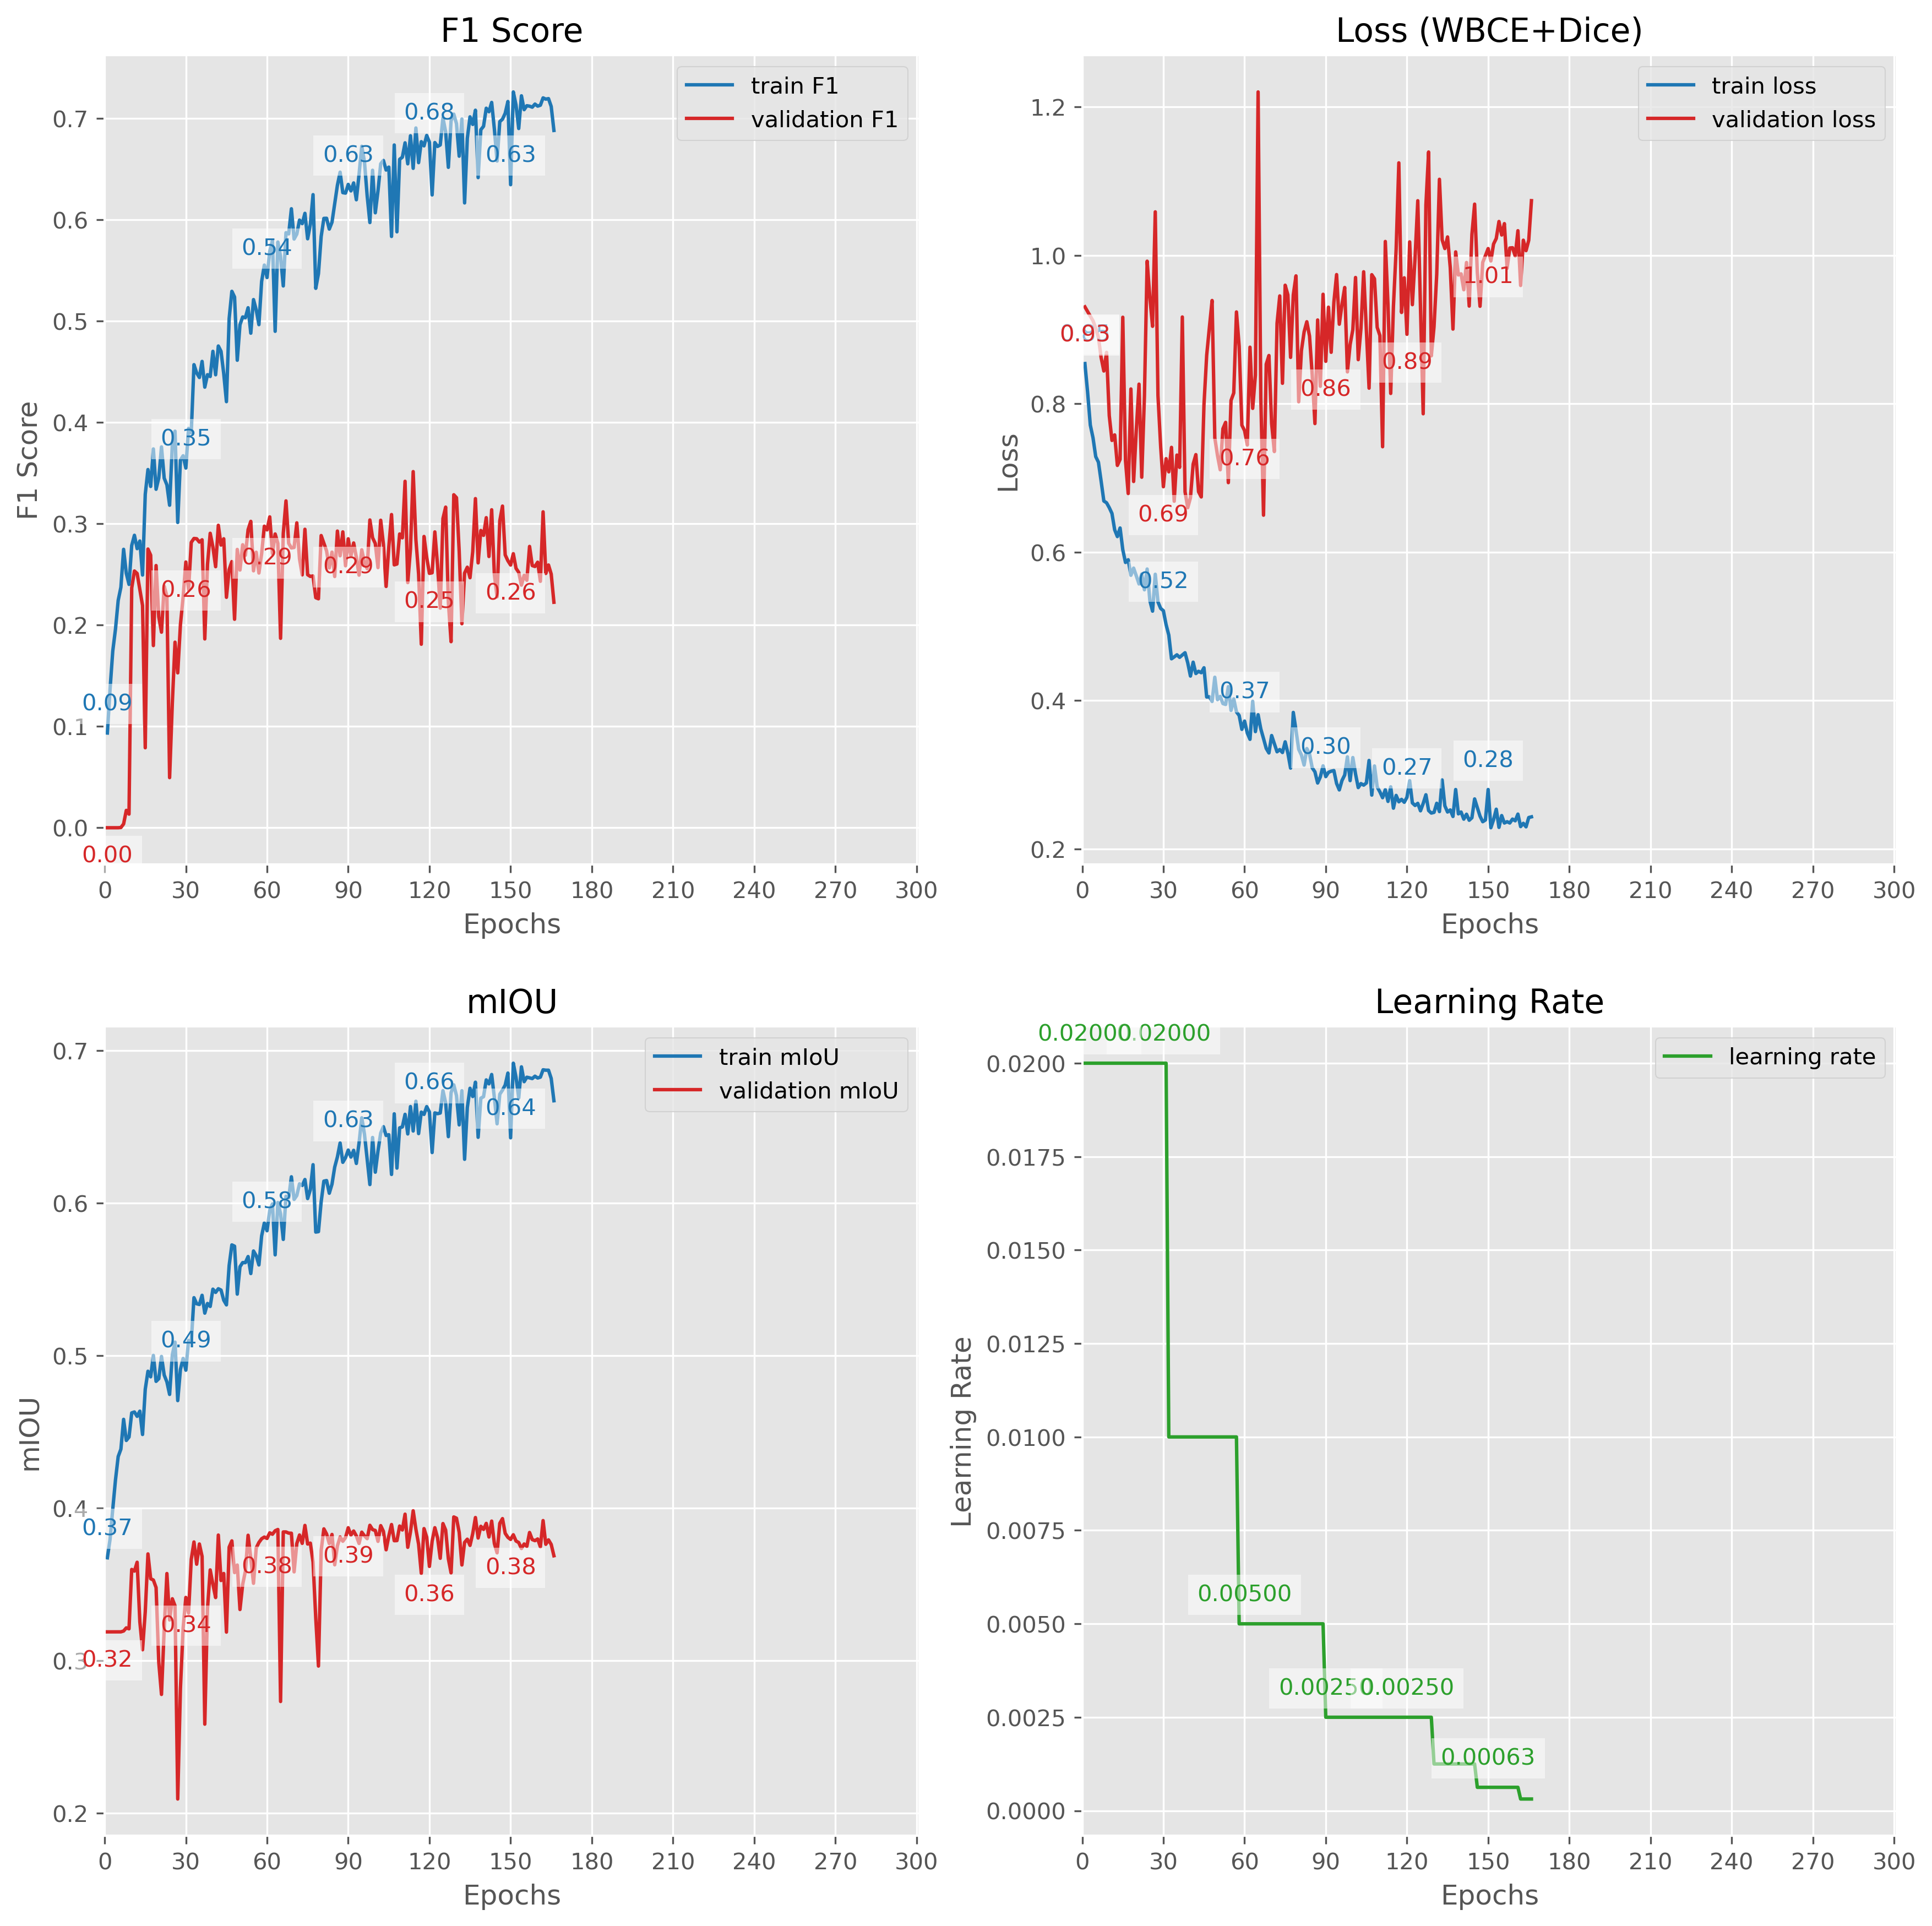

Early stopping triggered after 166 epochs.
TRAINING COMPLETE

Starting test set evaluation...


RUNNING TEST SET EVALUATION
Number of models to evaluate: 2
Models: ['best_maire_f1', 'best_iou']
Number of test zones: 2
Test zones: ['KAU_test', 'KAU_bbox']

Detailed test zone configuration:
  Zone 1: KAU_test
    Reserve: KAU
    Layer: unet_test_zone
    GPKG: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data\limited_extent\B_kauri_glen\E_gis\bbox.gpkg
  Zone 2: KAU_bbox
    Reserve: KAU
    Layer: bbox
    GPKG: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data\limited_extent\B_kauri_glen\E_gis\bbox.gpkg

Output mode: binary
Tile size: 576
Stitched predictions will be saved to: ../../5_3_unet\models\MS_REL_RENDVI_KAU\MW10_LR0_02_BCEDICE\test_predictions

Test metrics will be saved to: ../../5_3_unet\models\MS_REL_RENDVI_KAU\MW10_LR0_02_BCEDICE\test_metrics

100%|██████████| 1/1 [00:00<00:00,  2.60it/s]


  ✓ Created 2 image tiles

[2/5] Clipping labels for KAU_test...


Clipping GeoTIFFs: 100%|██████████| 2/2 [00:00<00:00, 48.44file/s]



  ✓ Created 2 label tiles

  🔍 DEBUGGING: Inspecting label tiles for maire pixels...
  ⚠️  WARNING: NO MAIRE PIXELS found in first 2 label tiles!
    This means the test zone may not overlap with maire labels

[3/5] Running inference for KAU_test...
  Using model: best_maire_f1


...

bbox ✓ 
Inference complete.

Evaluating stitched predictions...


Processing Reserves:   0%|          | 0/1 [00:00<?, ?it/s]


EVALUATING STITCHED PREDICTION
Model: best_maire_f1
Zone: KAU_unet_test_zone (layer: unet_test_zone)
Prediction: best_maire_f1_unet_test_zone.tif
Ground truth: swamp_maire_poly.gpkg / maire_poly_ms

[1/4] Loading zone polygon...
  ✓ Zone loaded: unet_test_zone

[2/4] Loading and clipping prediction to zone...
  ✓ Prediction clipped: (1008, 543)
    Unique values: [0 1]
    Predicted maire pixels: 9,012

[3/4] Rasterizing ground truth labels...
  ✓ Labels rasterized: (1008, 543)
    Unique values: [0 1]
    Ground truth maire pixels: 18,909

[4/4] Calculating metrics...

  ✓ Metrics calculated:
    mIoU:            0.5337
    Maire Precision: 0.3037
    Maire Recall:    0.1447
    Maire F1:        0.1961
    Maire IoU:       0.1087
    Confusion: TP=2,737, FP=6,275, FN=16,172, TN=522,160

  ✓ Results appended to: ../../5_3_unet\models\MS_REL_RENDVI_KAU\MW10_LR0_02_BCEDICE\test_predictions\best_maire_f1_unet_test_zone_metrics.csv

EVALUATION COMPLETE


EVALUATING STITCHED PREDICTION
Mod

Processing Reserves:   0%|          | 0/1 [08:33<?, ?it/s]


  ✓ Metrics calculated:
    mIoU:            0.5515
    Maire Precision: 0.1407
    Maire Recall:    0.6007
    Maire F1:        0.2280
    Maire IoU:       0.1287
    Confusion: TP=50,120, FP=306,044, FN=33,315, TN=12,881,561

  ✓ Results appended to: ../../5_3_unet\models\MS_REL_RENDVI_KAU\MW10_LR0_02_BCEDICE\test_predictions\best_iou_bbox_metrics.csv

EVALUATION COMPLETE



In [ ]:
import logging
from unet_2.pipeline import train_unet_pipeline

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

reserves_combs = [['ESK'], ['BUS'], ['HAM'], ['KAU']]
band_combs = ['ind_rel', 'rgb', 'ms_rel', 'ms_rel_rendvi']
loss_functions = ['bce', 'dice', 'bce_dice']
learning_rates = [0.02, 5e-5]
weights = [1, 10, 50]



for reserve_comb in reserves_combs:

    for band_comb in band_combs:
        if band_comb == 'rgb' or band_comb == 'ms_rel':  # FIXED: was band_combs (list) instead of band_comb (string)
            for lr in learning_rates:
                for weight in weights:# [10, 1, 50]:
                    for loss_func in loss_functions:
                        if loss_func == 'dice' and weight != 1:
                            continue  # Skip incompatible combo
                        
                        try:
                            train_unet_pipeline(
                                reserves = reserve_comb,
                                maire_weight = weight,
                                lr = lr,
                                loss_type=loss_func,  # Binary Cross-Entropy
                                bands_type=band_comb  # 'ms_rel', 'rgb', 'ms_bands', 'custom'
                            )
                        except Exception as e:
                            logger.error(f"Error training for reserves {reserve_comb} with bands {band_comb}: {e}", exc_info=True)
        else:
            try: 
                train_unet_pipeline(
                    reserves = reserve_comb,
                    maire_weight = 10,
                    lr = 0.02,
                    loss_type='bce_dice',  # Binary Cross-Entropy
                    bands_type=band_comb  # 'ms_rel', 'rgb', 'ms_bands', 'custom'
                )
            except Exception as e:
                logger.error(f"Error training for reserves {reserve_comb} with bands {band_comb}: {e}", exc_info=True)

## multi-site

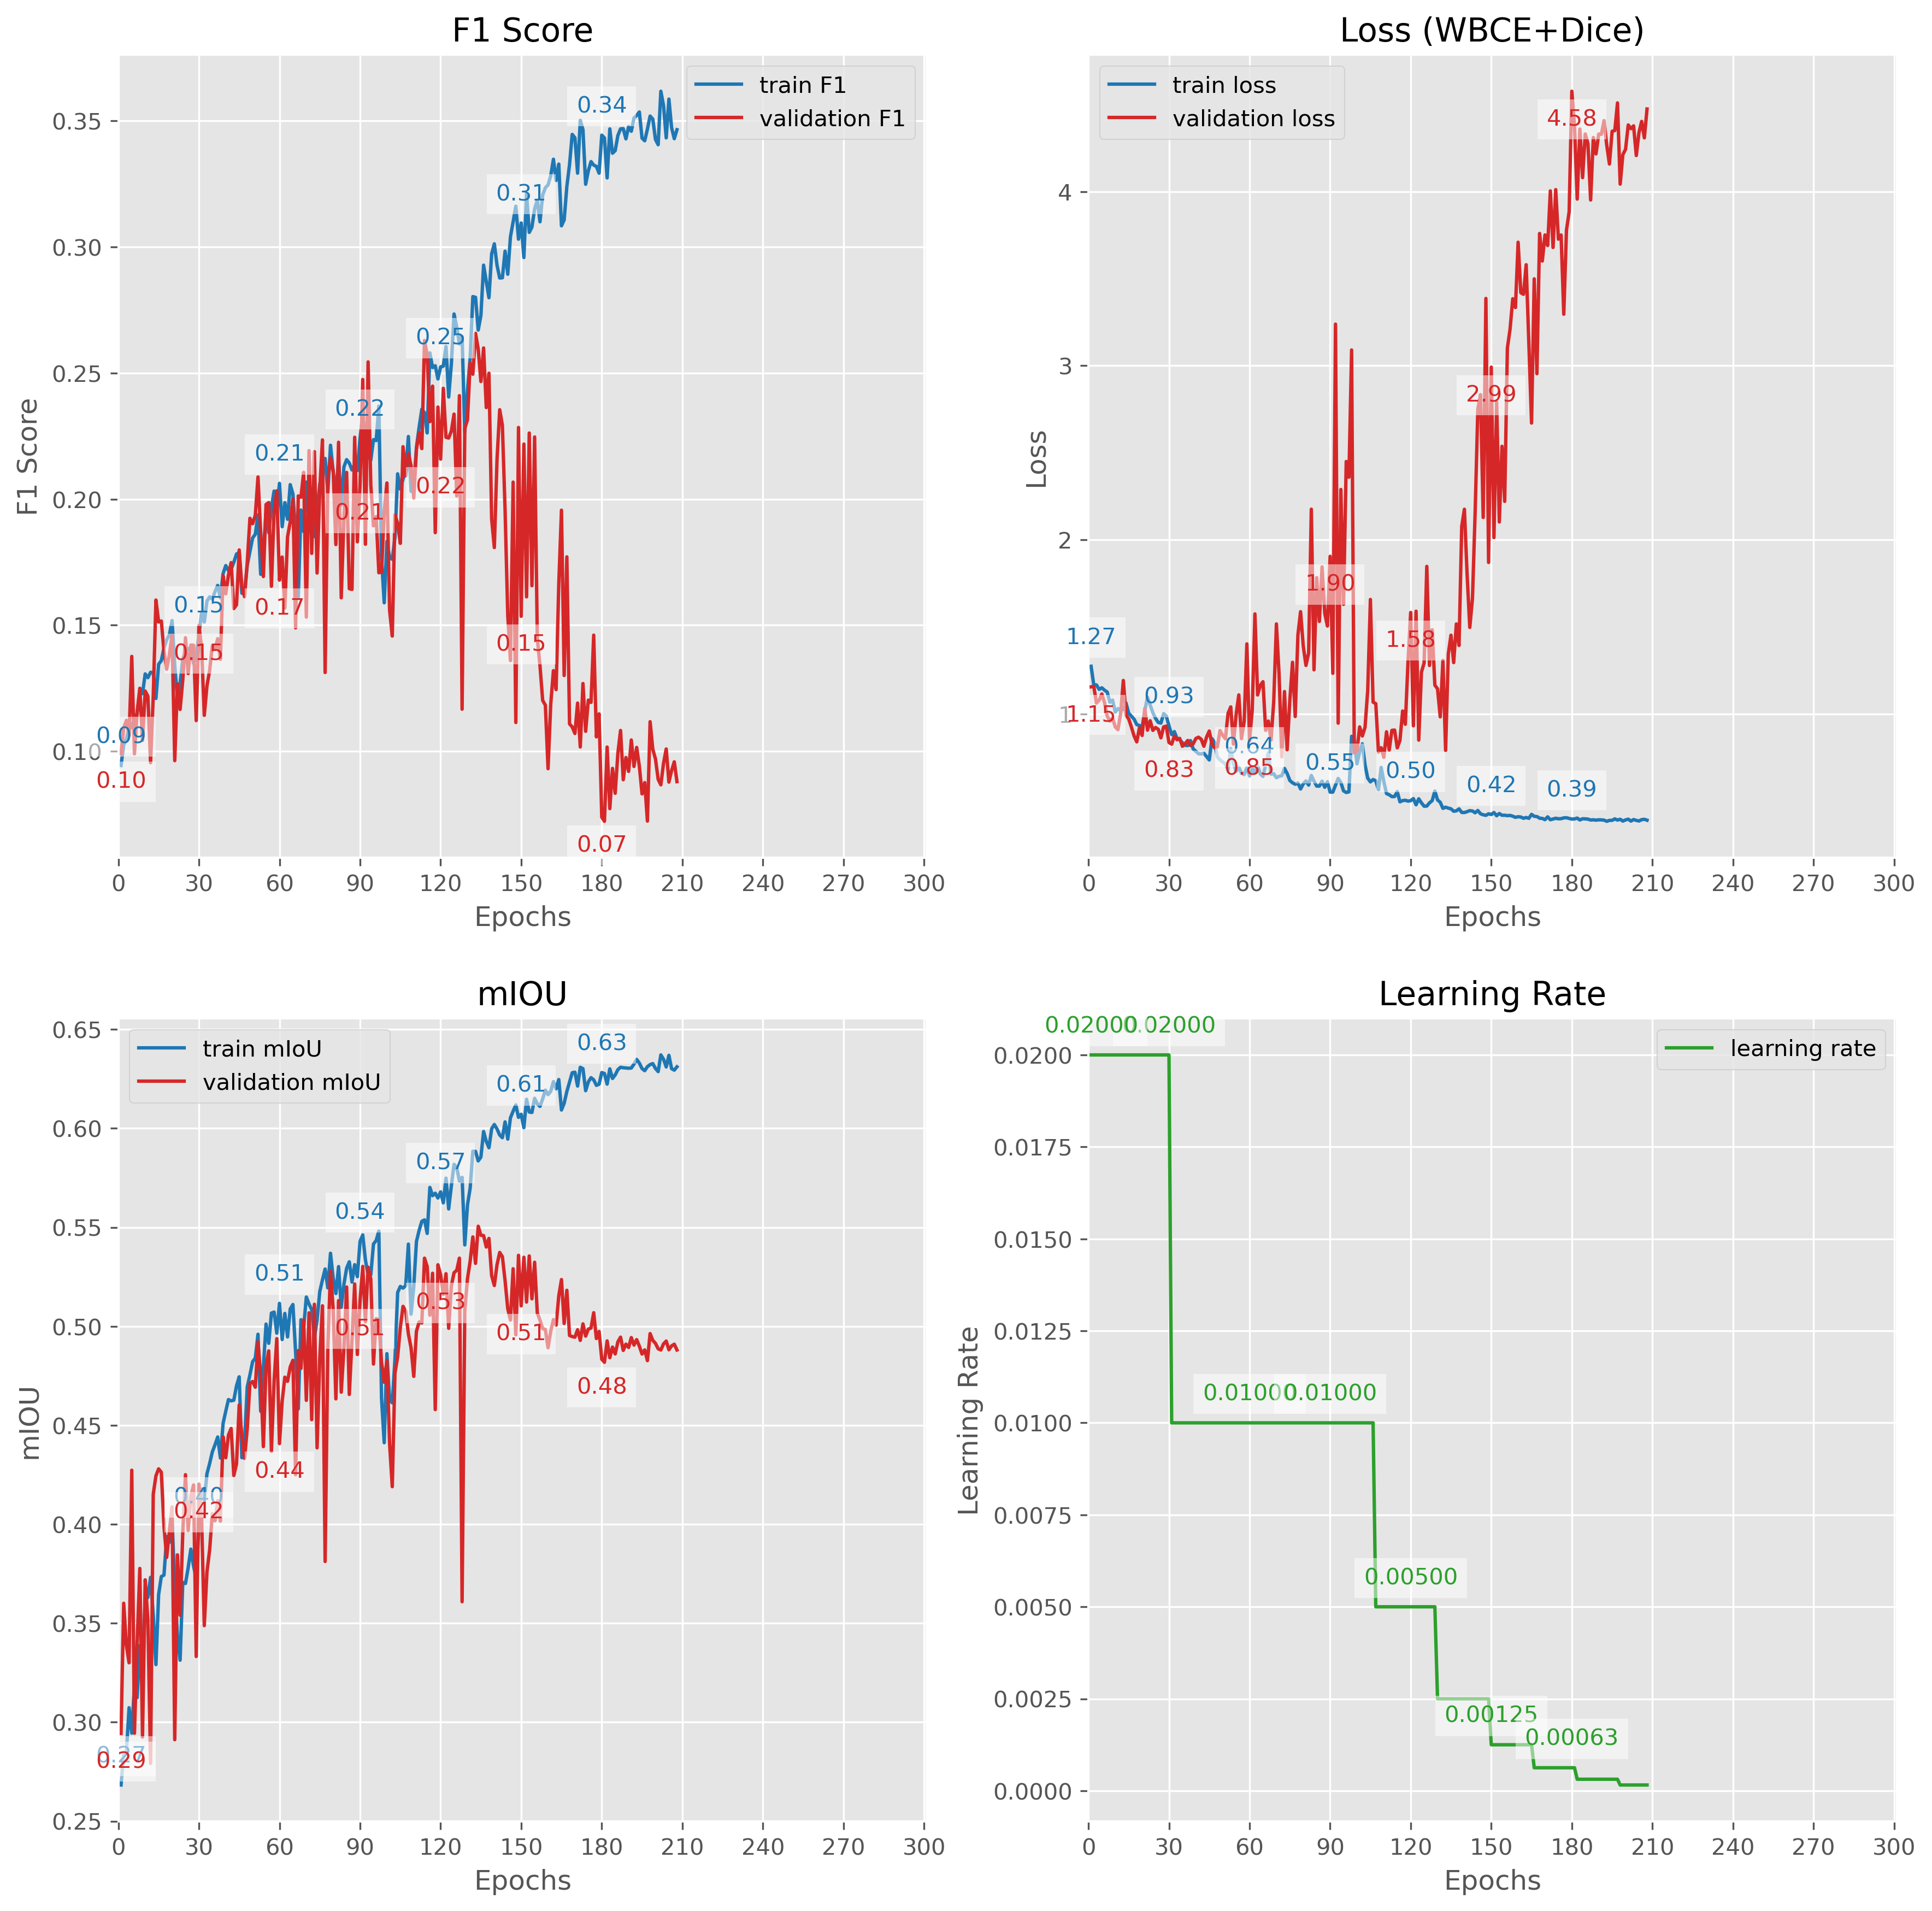

Early stopping triggered after 208 epochs.
TRAINING COMPLETE

Starting test set evaluation...


RUNNING TEST SET EVALUATION
Number of models to evaluate: 2
Models: ['best_maire_f1', 'best_iou']
Number of test zones: 8
Test zones: ['KAU_test', 'KAU_bbox', 'ESK_test', 'ESK_bbox', 'BUS_test', 'BUS_bbox', 'HAM_test', 'HAM_bbox']

Detailed test zone configuration:
  Zone 1: KAU_test
    Reserve: KAU
    Layer: unet_test_zone
    GPKG: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data\limited_extent\B_kauri_glen\E_gis\bbox.gpkg
  Zone 2: KAU_bbox
    Reserve: KAU
    Layer: bbox
    GPKG: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data\limited_extent\B_kauri_glen\E_gis\bbox.gpkg
  Zone 3: ESK_test
    Reserve: ESK
    Layer: unet_test_zone
    GPKG: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_d

100%|██████████| 1/1 [00:00<00:00,  3.45it/s]


  ✓ Created 3 image tiles

[2/5] Clipping labels for KAU_test...


Clipping GeoTIFFs: 100%|██████████| 3/3 [00:00<00:00, 45.64file/s]



  ✓ Created 3 label tiles

  🔍 DEBUGGING: Inspecting label tiles for maire pixels...
  ⚠️  WARNING: NO MAIRE PIXELS found in first 3 label tiles!
    This means the test zone may not overlap with maire labels

[3/5] Running inference for KAU_test...
  Using model: best_maire_f1


...


  ✓ Metrics calculated:
    mIoU:            0.5966
    Maire Precision: 0.3823
    Maire Recall:    0.3237
    Maire F1:        0.3506
    Maire IoU:       0.2125
    Confusion: TP=259,219, FP=418,811, FN=541,598, TN=48,567,508

  ✓ Results appended to: ../../5_3_unet\models\RGB_KAU_ESK_BUS_HAM\MW50_LR0_02_BCEDICE\test_predictions\best_iou_ESK_bbox_metrics.csv

EVALUATION COMPLETE


EVALUATING STITCHED PREDICTION
Model: best_maire_f1
Zone: BUS_unet_test_zone (layer: unet_test_zone)
Prediction: best_maire_f1_BUS_unet_test_zone.tif
Ground truth: swamp_maire_poly.gpkg / maire_poly_rgb

[1/4] Loading zone polygon...
  ✓ Zone loaded: unet_test_zone

[2/4] Loading and clipping prediction to zone...
  ✓ Prediction clipped: (1872, 1872)
    Unique values: [0 1]
    Predicted maire pixels: 556,042

[3/4] Rasterizing ground truth labels...
  ✓ Labels rasterized: (1872, 1872)
    Unique values: [0 1]
    Ground truth maire pixels: 271,392

[4/4] Calculating metrics...

  ✓ Metrics calculated:
 

Processing Reserves:  75%|███████▌  | 3/4 [00:11<00:04,  4.50s/it]


  ✓ Metrics calculated:
    mIoU:            0.5923
    Maire Precision: 0.2236
    Maire Recall:    0.7825
    Maire F1:        0.3478
    Maire IoU:       0.2105
    Confusion: TP=901,366, FP=3,129,756, FN=250,560, TN=127,184,180

  ✓ Results appended to: ../../5_3_unet\models\RGB_KAU_ESK_BUS_HAM\MW50_LR0_02_BCEDICE\test_predictions\best_iou_BUS_bbox_metrics.csv

EVALUATION COMPLETE


EVALUATING STITCHED PREDICTION
Model: best_maire_f1
Zone: HAM_unet_test_zone (layer: unet_test_zone)
Prediction: best_maire_f1_HAM_unet_test_zone.tif
Ground truth: swamp_maire_poly.gpkg / maire_poly_rgb

[1/4] Loading zone polygon...
  ✓ Zone loaded: unet_test_zone

[2/4] Loading and clipping prediction to zone...
  ✓ Prediction clipped: (1008, 1872)
    Unique values: [0 1]
    Predicted maire pixels: 106,978

[3/4] Rasterizing ground truth labels...
  ✓ Labels rasterized: (1008, 1872)
    Unique values: [0 1]
    Ground truth maire pixels: 25,519

[4/4] Calculating metrics...

  ✓ Metrics calculated:

Processing Reserves: 100%|██████████| 4/4 [00:13<00:00,  3.32s/it]

    Unique values: [0 1]
    Ground truth maire pixels: 231,157

[4/4] Calculating metrics...

  ✓ Metrics calculated:
    mIoU:            0.5978
    Maire Precision: 0.3201
    Maire Recall:    0.3724
    Maire F1:        0.3443
    Maire IoU:       0.2079
    Confusion: TP=86,088, FP=182,859, FN=145,069, TN=26,293,952

  ✓ Results appended to: ../../5_3_unet\models\RGB_KAU_ESK_BUS_HAM\MW50_LR0_02_BCEDICE\test_predictions\best_iou_HAM_bbox_metrics.csv

EVALUATION COMPLETE



In [2]:
import logging
from unet_2.pipeline import train_unet_pipeline

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

reserves = ['KAU', 'ESK', 'BUS', 'HAM']
band_combs = ['ms_abs', 'ms_rel', 'ms_abs_rendvi', 'ind_abs', 'rgb']
loss_functions = ['dice', 'bce_dice']

for band_comb in band_combs:
    for lr in [0.02]:
        for weight in [1, 10, 50]:
            for loss_func in loss_functions:
                if loss_func == 'dice' and weight != 1:
                    continue  # Skip incompatible combo
                elif loss_func != 'dice' and weight == 1:
                    continue  # Skip combo
                try:
                    train_unet_pipeline(
                        reserves = reserves,
                        maire_weight = weight,
                        lr = lr,
                        loss_type=loss_func,  # Binary Cross-Entropy
                        bands_type=band_comb  # 'ms_rel', 'rgb', 'ms_bands', 'custom'
                    )
                except Exception as e:
                    logger.error(f"Error training for reserves {reserves} with bands {band_comb}: {e}", exc_info=True)

# Figure

This script creates comparison plots showing:
1. RGB imagery (center 10×10m from test zone)
2. Ground truth labels
3. Predictions from multiple model configurations

Each model is specified with: `band_comb`, `lr`, `loss`, `weight`, and a `label` for display.

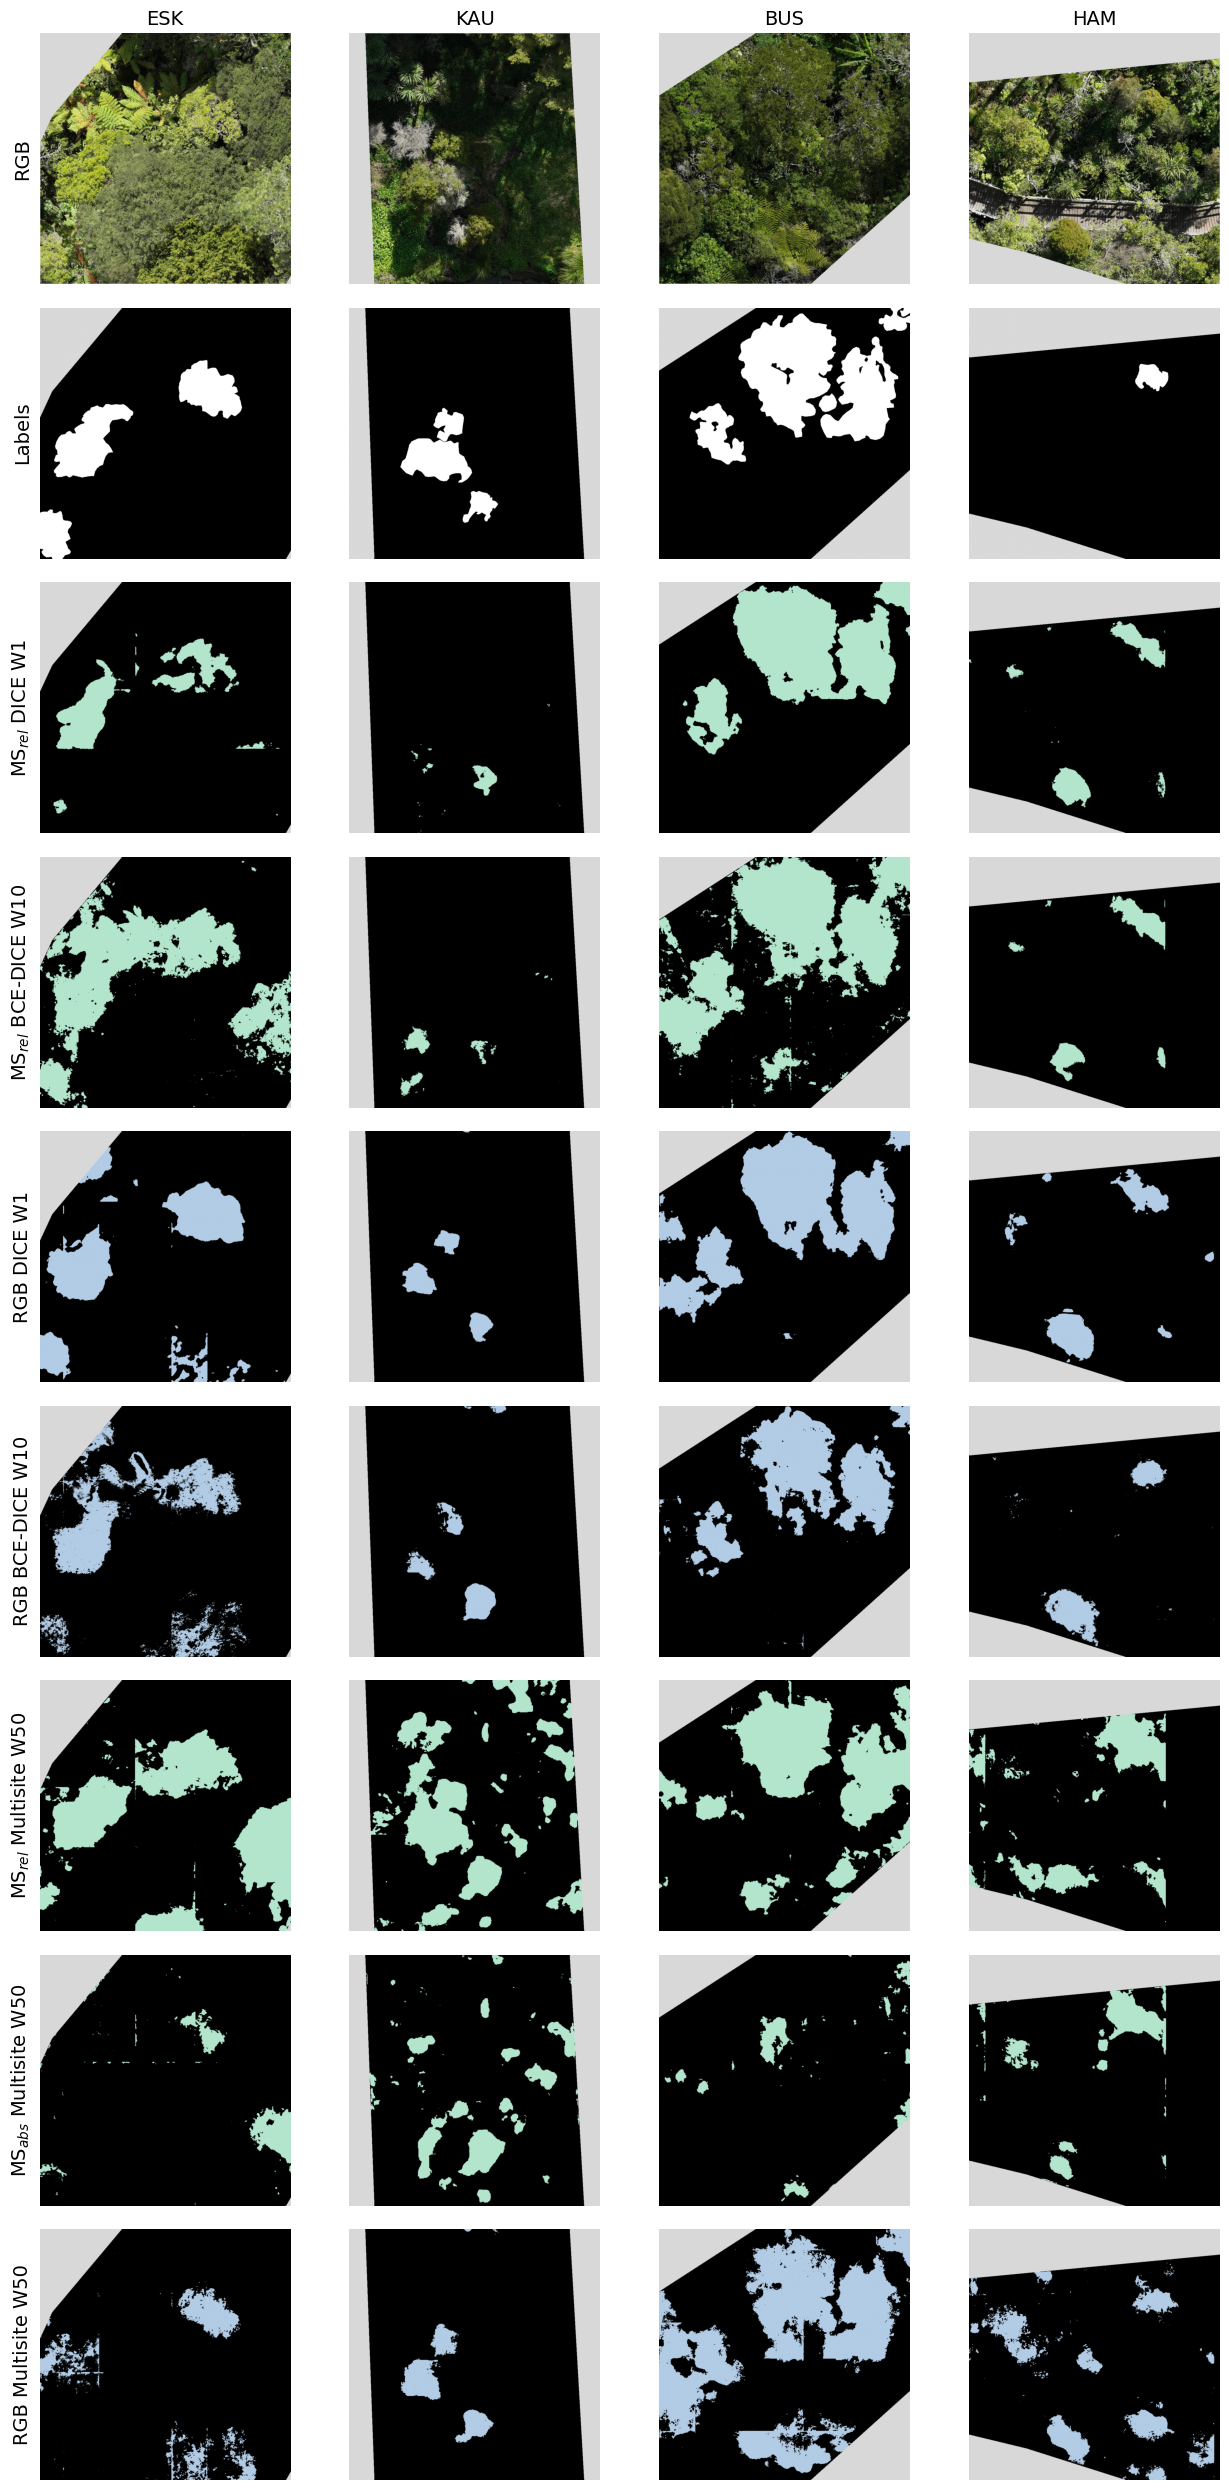

In [ ]:
# Example: Compare multiple models across reserves
from 2_1_figures.results.predictions import plot_model_comparisons

reserves = ['ESK', 'KAU', 'BUS', 'HAM']

# Define model configurations to compare
models_to_compare = [
    {'band_comb': 'ms_rel', 'lr': 0.02, 'loss': 'bce_dice', 'weight': 10, 'label': 'MS$_{rel}$ WBCE-D W10'},
    {'band_comb': 'rgb', 'lr': 0.02, 'loss': 'bce_dice', 'weight': 10, 'label': 'RGB WBCE-D W10'},
    {'band_comb': 'rgb', 'lr': 0.02, 'loss': 'dice', 'weight': 1, 'label': 'RGB DICE W1'},
]

# Generate comparison figures for each reserve
for reserve_code in reserves:
    print(f"\nGenerating comparison for {reserve_code}...")
    
    try:
        plot_model_comparisons(
            reserve_code=reserve_code,
            models=models_to_compare,
            layer='unet_test_zone',
            figsize=(20, 5),
            save_path=f'../../2_1_figures/results/model_comparison_{reserve_code}.png'
        )
    except Exception as e:
        print(f"Error generating comparison for {reserve_code}: {e}")